## 1. What this notebook computes

The pairing theorem T1 says that the field $\Gamma\Psi$ with the mass $-m$ and the
coupling $-\lambda$ carries exactly MINUS the energy-momentum tensor and MINUS the
current of the field $\Psi$ with $(m, \lambda)$, at every point of every
gravitational field. The Revision record draws one consequence for gravity, the
corollary **C1**: if such a pair is the ONLY source of the author's metric, the
source is zero, and in Einstein gravity the author's metric then has no solution
at all for $H > 0$. This notebook makes every step of C1 visible:

- it rebuilds the canonical spin connection of the author's metric (on the patch
  $0 < z < \pi/2$ of the hidden direction and on the mirror patch
  $\pi/2 < z < \pi$) and reproduces the record's twelve components and the term
  $\gamma^\mu\Omega_\mu = 3H\gamma^{(x_8)}$;
- it evaluates, for a configuration of the commuting field dirac16complex00, the
  energy-momentum tensor (all 64 components), the current and the field equation,
  and the same for its T1 partner $\Gamma\Psi$: the totals vanish at every point
  (two figures);
- it does the same for the T2 mirror copy across the Z2 brane $z = \pi/2$: there
  the tensor is EQUAL (pulled back), so the T2 pair does NOT cancel (two figures);
- it derives with sympy, from the record's components of the Einstein tensor,
  that the vacuum equations (zero source) have no real solution, and draws why
  (two figures);
- it shows which Einstein-Lovelock couplings admit the deflating linear member
  $a_4 = AHx_4$ as a vacuum, so that a T1 pair could live in it (two figures);
- it ends with a precise list of what C1 says and what it does not say.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 20a (Corollary C1: a T1 pair as the only source of the author's metric) is the
file `Revision/textbook/notebooks/20a_c1_zero_source.ipynb` of the repository
Dirac_claude. It reads the author's gamma matrices and builds the canonical spin
connection of the author's metric on the patch and on the mirror patch of the hidden
direction; it evaluates the energy-momentum tensor, the current and the field equation of
a configuration of dirac16complex00 and of its two partners, the T1 partner Gamma Psi
with mass and coupling reversed and the T2 mirror copy across the Z2 brane, and shows
that the T1 pair has zero total source at every point while the T2 pair has twice the
source of one member; it then derives with sympy, from the Revision record of the field
equations for a4, that the zero source has no solution in Einstein gravity for H greater
than 0 and any cosmological constant, and which Einstein-Lovelock couplings admit the
linear member a4 = A H x4 as a vacuum. It reproduces the Revision records where they
overlap and draws seven teaching figures. It needs a computer with Windows 11, macOS or
Linux, an internet connection for the installation, the program Git, and Python 3.12 or
newer (the notebooks were built with Python 3.14.5) with these packages at exactly these
versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10,
nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook
itself imports numpy, sympy and matplotlib; the other packages run Jupyter, the program
that shows and runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 20a_c1_zero_source.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 20 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 20a_c1_zero_source.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
20a_c1_zero_source.ipynb` (in the same folder, without running the cells again) to read
the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/20a.captions.json`
- `Revision/textbook/figures/20a_1_t1_pair_tensor.png`
- `Revision/textbook/figures/20a_2_pair_profiles.png`
- `Revision/textbook/figures/20a_3_t2_mirror_tensor.png`
- `Revision/textbook/figures/20a_4_einstein_vacuum_parabolas.png`
- `Revision/textbook/figures/20a_5_null_combination.png`
- `Revision/textbook/figures/20a_6_gauss_bonnet_vacuum.png`
- `Revision/textbook/figures/20a_7_third_order_vacua.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS every figure file of this notebook exists
    ALL 37 CHECKS PASSED (notebook 20a)

and the notebook must show 7 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/20a_c1_zero_source.ipynb` inside the folder Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "FileNotFoundError" naming a file below the folder Revision: the notebook reads nine
  files of the repository; it must be opened inside the folder
  Revision/textbook/notebooks of a complete copy of the repository made with git clone (a
  notebook copied alone to another folder cannot find them).

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 20a (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 20a (Corollary C1: a T1 pair as the only source of the author's metric) is the
# file Revision/textbook/notebooks/20a_c1_zero_source.ipynb of the repository
# Dirac_claude. It reads the author's gamma matrices and builds the canonical spin
# connection of the author's metric on the patch and on the mirror patch of the hidden
# direction; it evaluates the energy-momentum tensor, the current and the field equation
# of a configuration of dirac16complex00 and of its two partners, the T1 partner Gamma
# Psi with mass and coupling reversed and the T2 mirror copy across the Z2 brane, and
# shows that the T1 pair has zero total source at every point while the T2 pair has twice
# the source of one member; it then derives with sympy, from the Revision record of the
# field equations for a4, that the zero source has no solution in Einstein gravity for H
# greater than 0 and any cosmological constant, and which Einstein-Lovelock couplings
# admit the linear member a4 = A H x4 as a vacuum. It reproduces the Revision records
# where they overlap and draws seven teaching figures. It needs a computer with Windows
# 11, macOS or Linux, an internet connection for the installation, the program Git, and
# Python 3.12 or newer (the notebooks were built with Python 3.14.5) with these packages
# at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0,
# jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert
# 7.16.6. The notebook itself imports numpy, sympy and matplotlib; the other packages run
# Jupyter, the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 20a_c1_zero_source.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 20
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 20a_c1_zero_source.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 20a_c1_zero_source.ipynb (in the same folder, without running the cells again) to read
# the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/20a.captions.json
# - Revision/textbook/figures/20a_1_t1_pair_tensor.png
# - Revision/textbook/figures/20a_2_pair_profiles.png
# - Revision/textbook/figures/20a_3_t2_mirror_tensor.png
# - Revision/textbook/figures/20a_4_einstein_vacuum_parabolas.png
# - Revision/textbook/figures/20a_5_null_combination.png
# - Revision/textbook/figures/20a_6_gauss_bonnet_vacuum.png
# - Revision/textbook/figures/20a_7_third_order_vacua.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS every figure file of this notebook exists
#     ALL 37 CHECKS PASSED (notebook 20a)
#
# and the notebook must show 7 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/20a_c1_zero_source.ipynb inside the folder Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "FileNotFoundError" naming a file below the folder Revision: the notebook reads nine
#   files of the repository; it must be opened inside the folder
#   Revision/textbook/notebooks of a complete copy of the repository made with git clone
#   (a notebook copied alone to another folder cannot find them).
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "20a"  # this notebook: chapter 20, example a


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 20a complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Coordinates** $x_1, \dots, x_8$ (the author's names): $x_1, x_2, x_3$ ordinary
  3-space (inflating), $x_4$ the time, $x_5, x_6, x_7$ the three EXTRA TIMES (they
  deflate exponentially: their scale factor is $e^{-a_4}\sin^{1/6}z$ with $a_4$
  increasing), $x_8$ the hidden space direction with $z = 6Hx_8$. In the code the
  positions 0 to 7 of a list stand for $x_1$ to $x_8$.
- **Patch and mirror patch**: the author's metric is used on $0 < z < \pi/2$ (the
  patch). The map $z \to \pi - z$ carries it onto $\pi/2 < z < \pi$ (the mirror
  patch). The surface $z = \pi/2$ between them is called the **brane**; extending
  the field across it (the Z2 construction) is an ASSUMPTION of the record.
- **Gamma matrices** $\gamma^{(x_1)}, \dots, \gamma^{(x_8)}$: the author's real
  $16 \times 16$ matrices with $\gamma^{(a)}\gamma^{(b)} + \gamma^{(b)}\gamma^{(a)}
  = 2\eta^{ab}$, $\eta = \mathrm{diag}(+1,+1,+1,-1,-1,-1,-1,+1)$.
- **$C$** $= \gamma^{(x_8)}\gamma^{(x_1)}\gamma^{(x_2)}\gamma^{(x_3)}$; the adjoint
  is $\bar\Psi = \Psi^\dagger C$. **Chirality** $\Gamma = \gamma^{(x_8)}
  \gamma^{(x_1)}\cdots\gamma^{(x_7)} = \mathrm{diag}(-I_8, I_8)$.
- **Configuration**: a field $\Psi$ given by its 16 complex values and their 8
  first derivatives at a point (its first **jet**). A configuration need not solve
  the field equation; it is **on shell** when it does, **off shell** otherwise.
- **Pair** (in this notebook): a configuration together with a partner.
  **T1 partner**: $\Gamma\Psi$ with $(-m, -\lambda)$, at the same point.
  **T2 mirror copy**: $\gamma^{(x_8)}\Psi$ with $(-m, \lambda)$, placed at the
  mirror point $\pi - z$.
- **Energy-momentum tensor** $T_{\mu\nu}$: the source of gravity, 64 numbers at
  each point. **Energy density** $\rho$, **current** $J^\mu = -i\bar\Psi\gamma^\mu
  \Psi$, **charge density** $J^{x_4} = \Psi^\dagger B\Psi$.
- **Einstein tensor** $G^\mu{}_\nu$; **Lovelock tensors** $E_{(k)}{}^\mu{}_\nu$,
  $k = 1, 2, 3$ ($E_{(1)} = G$); couplings $\alpha_1, \alpha_2, \alpha_3$;
  **cosmological constant** $\Lambda$; gravitational coupling $\kappa$.
- **Vacuum equations**: the field equations of gravity with zero source,
  $\sum_k\alpha_kE_{(k)}{}^\mu{}_\nu + \Lambda\delta^\mu_\nu = 0$.
- **Linear member**: $a_4 = AHx_4 + a_0$; for $A > 0$ the extra times deflate as
  $e^{-AHx_4}$ while 3-space inflates as $e^{AHx_4}$. The author's history is
  $A = 1$.
- **Null combination** $\rho + p_8$: the energy density plus the pressure along
  $x_8$.
- **Corollary**: a statement that follows from a theorem in a few lines.

## 4. The physical and mathematical situation

Both fields of the theory have the Lagrangian density
$\mathcal{L}_{m,\lambda} = \sqrt{|g|}\,[K - mS - \tfrac\lambda2S^2]$ with
$K = \tfrac12(\bar\Psi\gamma^\mu D_\mu\Psi - (D_\mu\bar\Psi)\gamma^\mu\Psi)$ and
$S = \bar\Psi\Psi$. The pairing records use the energy-momentum tensor

$$T_{\mu\nu} = \tfrac14\big(\bar\Psi\gamma_\mu D_\nu\Psi + \bar\Psi\gamma_\nu D_\mu
\Psi - (D_\mu\bar\Psi)\gamma_\nu\Psi - (D_\nu\bar\Psi)\gamma_\mu\Psi\big)
- g_{\mu\nu}\,\mathcal{L}/\sqrt{|g|},$$

which is minus the tensor of the field-theory record; every statement below is
linear in $T$, so its sign convention does not matter. With it the energy
density is $\rho = -T_{x_4x_4}$.

**Theorem T1, part (T1c)** (PROVED in the Revision record):
$T^{(-m,-\lambda)}_{\mu\nu}[\Gamma\Psi] = -T^{(m,\lambda)}_{\mu\nu}[\Psi]$ and
$J^\mu[\Gamma\Psi] = -J^\mu[\Psi]$ at every point, off and on shell, in every
gravitational field, for both fields.

**Corollary C1** (PROVED in the record). *Hypotheses:* (i) the gravitational field
is the author's metric with the Einstein-Lovelock equations
$\sum_{k=1}^3\alpha_kE_{(k)}{}^\mu{}_\nu + \Lambda\delta^\mu_\nu = \kappa
T^\mu{}_\nu$; (ii) the complete source is the sum of the classical tensors of the
two members of a T1 pair at the same points of the same patch; (iii) nothing else
sources the metric. *Statement:* the source vanishes, so $a_4$ must solve the
vacuum equations; (a) in Einstein gravity ($\alpha_1 = 1$, $\alpha_2 = \alpha_3 =
0$) these have no real solution for $H > 0$ and any $\Lambda$; (b) in
Einstein-Lovelock gravity the linear member needs $V = 0$ (the vacuum factor of
section 12).

**Proof of (a), line by line.**

1. By hypothesis (ii) the source is $T^\mu{}_\nu[\Psi; m, \lambda] +
   T^\mu{}_\nu[\Gamma\Psi; -m, -\lambda]$.
2. By (T1c) the second term is minus the first, so the source is $0$.
3. The field equations become $G^\mu{}_\nu + \Lambda\delta^\mu_\nu = 0$.
4. The record gives $G^{x_4}{}_{x_4} = 3a_4'^2 + 21H^2$ and
   $G^{x_8}{}_{x_8} = -3a_4'^2 + 15H^2$, so two of the equations read
   $3a_4'^2 + 21H^2 + \Lambda = 0$ and $-3a_4'^2 + 15H^2 + \Lambda = 0$.
5. Subtracting the second from the first removes $\Lambda$:
   $6a_4'^2 + 6H^2 = 0$.
6. For a real function $a_4$ the left side is at least $6H^2$, which is positive
   for $H > 0$. Line 5 is false, so no real $a_4$ solves the equations.

Sections 5 to 10 below check lines 1 and 2 numerically, point by point; sections
11 to 14 check lines 3 to 6 and part (b) with sympy.

**Status words.** PROVED: an exact statement with a proof (the record's, or this
notebook's exact computation). COMPUTED: a floating-point result with its error.
ASSUMED: a hypothesis. The Z2 brane and the mirror patch are ASSUMED.

## 5. The Revision records this notebook reproduces

The next cell defines three helpers: `read_json` reads a JSON file of the
repository; `record_verdict` finds a check by its name in a Revision report and
returns its verdict; `reproduces` is a check that passes only when this notebook's
own result holds AND the named record check has the verdict PASS (it prints the
two lines PASS and reproduces together). Then it reads the sentence of the
record's document that states C1, and the counts of the two pairing reports.

In [2]:
import contextlib  # redirect_stdout: send printed lines into a buffer
import io  # StringIO: a text buffer in memory

GAMMAS = "Revision/algebra/gammas.json"  # the author's gamma matrices
PROOFS = "Revision/docs/PAIR_CREATION_PROOFS.md"  # the pairing document
PAIR_PY = "Revision/pairing/reports/python-pairing.json"  # sympy pairing record
PAIR_WL = "Revision/pairing/reports/wolfram-pairing.json"  # Wolfram pairing record
A4_RECORD = "Revision/field_equations_a4/a4-equations.json"  # the a4 equations
A4_PY = "Revision/field_equations_a4/reports/python-a4-report.json"
A4_WL = "Revision/field_equations_a4/reports/wolfram-a4-report.json"
LEAD_EGB = "Revision/lead_checks/reports/einstein-gauss-bonnet-a4.json"
LEAD_EMT = "Revision/lead_checks/reports/emt-divergence-and-spin-connection.json"


def read_json(relative):
    """Read a JSON file of the repository (a Revision record)."""
    return json.loads(repository_file(relative).read_text(encoding="utf-8"))


def record_verdict(report_file, name):
    """The verdict ("PASS") of the check called name in a report; None if absent."""
    for entry in read_json(report_file)["checks"]:
        if entry["name"] == name:
            return entry["verdict"]
    return None


def reproduces(condition, name, report_file, record_name):
    """A check that also requires the record check record_name to be PASS."""
    found = record_verdict(report_file, record_name) == "PASS"
    lines = io.StringIO()  # a text buffer
    with contextlib.redirect_stdout(lines):  # print() now writes into the buffer
        check(condition and found, name,
              record=f"{report_file}, check {record_name}")
    print(lines.getvalue(), end="")  # both lines with one print call


proofs = repository_file(PROOFS).read_text(encoding="utf-8")
C1_WORDS = ("a T1 pair taken as the complete classical source of the author's "
            "metric is a zero source, and the Einstein equations then have no "
            "solution for")
say(f"{PROOFS} says: \"{C1_WORDS} H > 0.\"")
check(C1_WORDS in proofs, "the record states the corollary C1")
wolfram_counts = read_json(PAIR_WL)["summary"]  # passed, failed, total
sympy_counts = read_json(PAIR_PY)["counts"]  # pass, fail, pending
passed, total = wolfram_counts["passed"], wolfram_counts["total"]
say(f"pairing reports: Wolfram {passed} of {total} PASS, sympy "
    f"{sympy_counts["pass"]} PASS and {sympy_counts["fail"]} FAIL")
check(wolfram_counts["passed"] == wolfram_counts["total"] == 101
      and sympy_counts["pass"] == 66 and sympy_counts["fail"] == 0,
      "both pairing reports pass every check (101 and 66)")

Revision/docs/PAIR_CREATION_PROOFS.md says: "a T1 pair taken as the complete classical
    source of the author's metric is a zero source, and the Einstein equations then have
    no solution for H > 0."
PASS the record states the corollary C1
pairing reports: Wolfram 101 of 101 PASS, sympy 66 PASS and 0 FAIL
PASS both pairing reports pass every check (101 and 66)


## 6. The author's gamma matrices, $C$ and the chirality $\Gamma$

The next cell reads the eight gamma matrices from `gammas.json` (whole numbers,
which `sp.Rational` turns into exact numbers), checks the 64 Clifford relations,
and builds $C$, the chirality $\Gamma$ and the generators
$S^{ab} = \tfrac14[\gamma^{(a)}, \gamma^{(b)}]$. It checks the three facts T1
needs (Lemma 1 of the record): $\Gamma = \mathrm{diag}(-I_8, I_8)$, $\Gamma$
anticommutes with every gamma, and $\Gamma$ commutes with $C$. Finally it makes
floating-point copies (numpy arrays) for the numerical part.

In [3]:
import itertools  # loops over all combinations of indices

import numpy as np  # floating-point arrays
import sympy as sp  # exact algebra

NAMES = ["x1", "x2", "x3", "x4", "x5", "x6", "x7", "x8"]  # positions 0..7
ETA = [1, 1, 1, -1, -1, -1, -1, 1]  # the frame metric eta, in the order x1..x8
I16 = sp.eye(16)  # the 16 by 16 unit matrix
fixture = read_json(GAMMAS)
gamma = [sp.Matrix([[sp.Rational(x) for x in row] for row in matrix])
         for matrix in fixture["gamma"]]  # gamma[a] = gamma^(x_(a+1)), exact
clifford = all(gamma[a] * gamma[b] + gamma[b] * gamma[a]
               == (2 * ETA[a] if a == b else 0) * I16
               for a in range(8) for b in range(8))
C = gamma[7] * gamma[0] * gamma[1] * gamma[2]  # C = g^(x8) g^(x1) g^(x2) g^(x3)
reproduces(clifford and C == C.T and C * C == I16
           and all((C * g).T == -(C * g) for g in gamma),
           "Clifford relation; C real symmetric, C^2 = 1, C gamma antisymmetric",
           PAIR_PY, "gammas.C")
chirality = gamma[7]  # the product g^(x8) g^(x1) ... g^(x7), built factor by factor
for a in range(7):
    chirality = chirality * gamma[a]
reproduces(chirality == sp.diag(*([-1] * 8 + [1] * 8)),
           "Gamma = diag(-I8, I8)", PAIR_PY, "gammas.Gamma")
reproduces(all(chirality * g == -g * chirality for g in gamma)
           and chirality * C == C * chirality,
           "Gamma anticommutes with every gamma and commutes with C",
           PAIR_WL, "Gamma_properties")
S_exact = [[(gamma[a] * gamma[b] - gamma[b] * gamma[a]) / 4 for b in range(8)]
           for a in range(8)]  # the generators S^ab
to_numpy = lambda matrix: np.array(matrix.tolist(), dtype=float)  # noqa: E731
gamma_num = [to_numpy(g) for g in gamma]  # floating-point copies
C_num, Gamma_num = to_numpy(C), to_numpy(chirality)
S_num = [[to_numpy(S_exact[a][b]) for b in range(8)] for a in range(8)]
B_num = -1j * C_num @ gamma_num[3]  # B = -i C gamma^(x4): J^x4 = Psi^dagger B Psi

PASS Clifford relation; C real symmetric, C^2 = 1, C gamma antisymmetric
     reproduces Revision/pairing/reports/python-pairing.json, check gammas.C
PASS Gamma = diag(-I8, I8)
     reproduces Revision/pairing/reports/python-pairing.json, check gammas.Gamma
PASS Gamma anticommutes with every gamma and commutes with C
     reproduces Revision/pairing/reports/wolfram-pairing.json, check Gamma_properties


## 7. The author's metric and its spin connection, on both patches

The vielbein of the author's diagonal metric is diagonal, $e^a{}_\mu =
E_a\delta^a_\mu$, with the lengths $E = (e^{a_4}s, e^{a_4}s, e^{a_4}s, 1,
e^{-a_4}s, e^{-a_4}s, e^{-a_4}s, s_8\cot z)$, $s = \sin^{1/6}z$. On the patch
$\cot z > 0$ and $s_8 = +1$; on the mirror patch $\cot z < 0$, and its own
positive vielbein has $s_8 = -1$ (the record's construction). The canonical spin
connection is $\omega_\mu{}^a{}_b = e^a{}_\nu(\partial_\mu e_b{}^\nu +
\Gamma^\nu{}_{\mu\lambda}e_b{}^\lambda)$ with the inverse vielbein $e_b{}^\nu =
\delta^\nu_b/E_b$. For $a = b$ the two terms cancel; for $a \neq b$ only the second
survives, and lowering $a$ with $\eta$:

$$\omega_{\mu\,ab} = \eta_{aa}\,\frac{E_a}{E_b}\,\Gamma^a{}_{\mu b}
\qquad (a \neq b).$$

The Christoffel symbols of a diagonal metric are
$\Gamma^a{}_{bc} = (\delta_{ac}\partial_bg_{aa} + \delta_{ab}\partial_cg_{aa} -
\delta_{bc}\partial_ag_{bb})/(2g_{aa})$ (no sum), and $\partial/\partial x_8 =
6H\,\partial/\partial z$ because $z = 6Hx_8$. The next cell computes all
$\omega_{\mu ab}$ with sympy for an arbitrary function $a_4(x_4)$, on both patches;
at a point $a_4$ and $a_4'$ become the numbers `a4_value` and `slope`.

In [4]:
H = sp.symbols("H", positive=True)  # the author's constant H > 0
z = sp.symbols("z", real=True)  # the hidden coordinate z = 6 H x8
x4 = sp.symbols("x4", real=True)  # the time
a4 = sp.Function("a4")(x4)  # the metric function a4(x4), arbitrary
a4_value, slope = sp.symbols("a4_value slope", real=True)  # a4 and a4' at a point


def lengths(s8):
    """The lengths E_a of the diagonal vielbein; s8 = +1 on the patch, -1 on the
    mirror patch (where cot z < 0, so -cot z is the positive length)."""
    s = sp.sin(z) ** sp.Rational(1, 6)  # the warp sin(z)^(1/6) of a length
    return ([sp.exp(a4) * s] * 3 + [sp.Integer(1)] + [sp.exp(-a4) * s] * 3
            + [s8 * sp.cot(z)])


def d(expr, mu):
    """The partial derivative along the coordinate at position mu."""
    if mu == 3:
        return sp.diff(expr, x4)
    if mu == 7:
        return 6 * H * sp.diff(expr, z)  # d/dx8 = 6 H d/dz
    return sp.Integer(0)  # nothing depends on x1, x2, x3, x5, x6, x7


def spin_connection(s8):
    """The lengths E_a and omega[mu][a][b] = omega_mu ab at a point (a4 and a4'
    replaced by the symbols a4_value and slope)."""
    E = lengths(s8)
    g = [ETA[a] * E[a] ** 2 for a in range(8)]  # the metric g_aa
    christoffel = {}
    for a, b, c in itertools.product(range(8), repeat=3):
        value = 0  # the formula of the markdown cell, term by term
        if a == c:
            value += d(g[a], b)
        if a == b:
            value += d(g[a], c)
        if b == c:
            value -= d(g[b], a)
        christoffel[a, b, c] = value / (2 * g[a])
    omega = [[[sp.Integer(0)] * 8 for _ in range(8)] for _ in range(8)]
    for mu, a, b in itertools.product(range(8), repeat=3):
        if a != b:
            value = ETA[a] * E[a] * christoffel[a, mu, b] / E[b]
            value = value.subs(sp.Derivative(a4, x4), slope).subs(a4, a4_value)
            omega[mu][a][b] = sp.simplify(value)
    return [length.subs(a4, a4_value) for length in E], omega


E_patch, omega_patch = spin_connection(1)
E_mirror, omega_mirror = spin_connection(-1)
for label, omega in (("patch", omega_patch), ("mirror patch", omega_mirror)):
    count = sum(1 for mu in range(8) for a in range(8) for b in range(a + 1, 8)
                if omega[mu][a][b] != 0)
    say(f"{label}: {count} nonzero components omega_mu ab with a < b")

patch: 12 nonzero components omega_mu ab with a < b
mirror patch: 12 nonzero components omega_mu ab with a < b


The record lists the twelve nonzero components on the patch ($a < b$; with
$u = e^{a_4}\sin^{1/6}z$ and $v = e^{-a_4}\sin^{1/6}z$): $\omega_{x_i,\,x_ix_4} =
a_4'u$ and $\omega_{x_i,\,x_ix_8} = Hu$ for the three inflating directions
$i = 1, 2, 3$; $\omega_{x_t,\,x_4x_t} = -a_4'v$ and $\omega_{x_t,\,x_tx_8} = -Hv$
for the three DEFLATING extra times $t = 5, 6, 7$. The next cell compares, builds
$\Omega_\mu = \tfrac12\sum_{a,b}\omega_{\mu ab}S^{ab}$, and checks the record's
$\sum_\mu\gamma^\mu\Omega_\mu = 3H\gamma^{(x_8)}$ on the patch ($\gamma^\mu =
\gamma^{(\mu)}/E_\mu$). On the mirror patch the $x_8$ components change sign and
the sum is $-3H\gamma^{(x_8)}$ (computed here). It also checks that $z \to \pi - z$
leaves every metric component unchanged (the mirror is an isometry).

In [5]:
s = sp.sin(z) ** sp.Rational(1, 6)
u, v = sp.exp(a4_value) * s, sp.exp(-a4_value) * s
expected = {}  # (mu, a, b) -> the record's component, on the patch
for i in (0, 1, 2):  # the inflating 3-space directions
    expected[i, i, 3], expected[i, i, 7] = slope * u, H * u
for t in (4, 5, 6):  # the deflating extra times
    expected[t, 3, t], expected[t, t, 7] = -slope * v, -H * v


def components(omega):
    """The nonzero omega_mu ab with a < b, as a dictionary."""
    return {(mu, a, b): omega[mu][a][b] for mu in range(8) for a in range(8)
            for b in range(a + 1, 8) if omega[mu][a][b] != 0}


def same_components(found, wanted):
    return set(found) == set(wanted) and all(
        sp.simplify(found[key] - wanted[key]) == 0 for key in wanted)


reproduces(same_components(components(omega_patch), expected),
           "the twelve spin-connection components of the record (patch)",
           PAIR_PY, "geometry.spin_connection_components")
flipped = {key: (-value if 7 in key[1:] else value)
           for key, value in expected.items()}  # x8 components change sign
reproduces(same_components(components(omega_mirror), flipped),
           "mirror patch: the x8 components change sign, the others do not",
           PAIR_WL, "connection_mirror_patch")
Omega = {}  # s8 -> the eight matrices Omega_mu
for s8, omega in ((1, omega_patch), (-1, omega_mirror)):
    Omega[s8] = [sum((omega[mu][a][b] * S_exact[a][b] / 2 for a in range(8)
                      for b in range(8) if omega[mu][a][b] != 0), sp.zeros(16))
                 for mu in range(8)]
term = {}  # s8 -> sum over mu of gamma^mu Omega_mu
for s8, E in ((1, E_patch), (-1, E_mirror)):
    term[s8] = sum((gamma[mu] / E[mu] * Omega[s8][mu] for mu in range(8)),
                   sp.zeros(16)).applyfunc(sp.simplify)
reproduces(term[1] == 3 * H * gamma[7], "patch: gamma^mu Omega_mu = 3 H gamma^(x8)",
           LEAD_EMT, "gamma_Omega_equals_3H_gamma8")
check(term[-1] == -3 * H * gamma[7], "mirror patch: gamma^mu Omega_mu = -3 H gamma^(x8)")
g_patch = [ETA[a] * E_patch[a] ** 2 for a in range(8)]
reproduces(all(sp.simplify(entry.subs(z, sp.pi - z) - entry) == 0
               for entry in g_patch),
           "z -> pi - z leaves all eight metric components unchanged",
           PAIR_PY, "geometry.mirror_isometry")

PASS the twelve spin-connection components of the record (patch)
     reproduces Revision/pairing/reports/python-pairing.json, check
    geometry.spin_connection_components
PASS mirror patch: the x8 components change sign, the others do not
     reproduces Revision/pairing/reports/wolfram-pairing.json, check
    connection_mirror_patch
PASS patch: gamma^mu Omega_mu = 3 H gamma^(x8)
     reproduces Revision/lead_checks/reports/emt-divergence-and-spin-connection.json,
    check gamma_Omega_equals_3H_gamma8
PASS mirror patch: gamma^mu Omega_mu = -3 H gamma^(x8)
PASS z -> pi - z leaves all eight metric components unchanged
     reproduces Revision/pairing/reports/python-pairing.json, check
    geometry.mirror_isometry


## 8. A configuration and its T1 partner at one point

From here on we work with floating-point numbers. The next cell turns the
lengths and the connection into numpy functions (`sp.lambdify`) and defines two
helpers. `geometry_at(s8, z, a4, a4', H)` returns, at one point, the lengths, the
metric, the eight $\Omega_\mu$ and the curved gammas $\gamma^\mu = \gamma^{(\mu)}/
E_\mu$ and $\gamma_\mu = g_{\mu\mu}\gamma^\mu$. `bilinears(at, psi, dpsi, m, lam)`
evaluates, for the first jet (the value `psi` and the eight first derivatives
`dpsi[mu]`), the quantities of section 4 term by term:
$\bar\Psi = \Psi^\dagger C$, $D_\mu\Psi = \partial_\mu\Psi + \Omega_\mu\Psi$,
$D_\mu\bar\Psi = \partial_\mu\bar\Psi - \bar\Psi\Omega_\mu$, $S$, $K$,
$\mathcal{L}/\sqrt{|g|}$, the 64 components $T_{\mu\nu}$, the current $J^\mu$ and
the field-equation residual $E_{m,\lambda} = \gamma^\mu D_\mu\Psi - (m + \lambda S)
\Psi$ (zero exactly when the configuration solves the field equation).

In [6]:
point_symbols = (z, a4_value, slope, H)
NUMERIC = {}  # s8 -> (the function of the lengths, the connection pieces)
for s8, E, omega in ((1, E_patch, omega_patch), (-1, E_mirror, omega_mirror)):
    lengths_f = sp.lambdify(point_symbols, E, "numpy")
    pieces = [(mu, a, b, sp.lambdify(point_symbols, omega[mu][a][b], "numpy"))
              for mu in range(8) for a in range(8) for b in range(8)
              if omega[mu][a][b] != 0]
    NUMERIC[s8] = (lengths_f, pieces)


def geometry_at(s8, z_value, a4_number, slope_number, H_number=1.0):
    """Lengths, metric, Omega_mu and the curved gammas at one point."""
    lengths_f, pieces = NUMERIC[s8]
    values = (z_value, a4_number, slope_number, H_number)
    E = np.array([float(x) for x in lengths_f(*values)])
    Om = [np.zeros((16, 16)) for _ in range(8)]
    for mu, a, b, f in pieces:  # Omega_mu = (1/2) sum omega_mu ab S^ab
        Om[mu] += float(f(*values)) * S_num[a][b] / 2
    return {"g": np.array(ETA) * E ** 2, "Omega": Om,
            "up": [gamma_num[mu] / E[mu] for mu in range(8)],
            "down": [ETA[mu] * E[mu] * gamma_num[mu] for mu in range(8)]}


def bilinears(at, psi, dpsi, m, lam):
    """S, K, L/sqrt|g|, T_mu nu, J^mu, the field-equation residual, and the
    largest imaginary part of a quantity that must be real."""
    bar = psi.conj() @ C_num  # Psibar = Psi^dagger C (a row)
    dbar = [row.conj() @ C_num for row in dpsi]  # d_mu Psibar
    D = [dpsi[mu] + at["Omega"][mu] @ psi for mu in range(8)]  # D_mu Psi
    Dbar = [dbar[mu] - bar @ at["Omega"][mu] for mu in range(8)]  # D_mu Psibar
    S = bar @ psi
    K = 0.5 * sum(bar @ at["up"][mu] @ D[mu] - Dbar[mu] @ at["up"][mu] @ psi
                  for mu in range(8))
    L = K - m * S - lam / 2 * S ** 2  # L / sqrt|g|
    T = np.zeros((8, 8), dtype=complex)
    for mu, nu in itertools.product(range(8), repeat=2):
        T[mu, nu] = 0.25 * (bar @ at["down"][mu] @ D[nu]
                            + bar @ at["down"][nu] @ D[mu]
                            - Dbar[mu] @ at["down"][nu] @ psi
                            - Dbar[nu] @ at["down"][mu] @ psi)
        if mu == nu:
            T[mu, nu] -= at["g"][mu] * L
    J = np.array([-1j * bar @ at["up"][mu] @ psi for mu in range(8)])
    residual = sum(at["up"][mu] @ D[mu] for mu in range(8)) - (m + lam * S) * psi
    imaginary = max(abs(S.imag), abs(K.imag), np.abs(T.imag).max(),
                    np.abs(J.imag).max())
    return {"S": S.real, "K": K.real, "L": L.real, "T": T.real, "J": J.real,
            "E": residual, "imag": imaginary}

The next cell chooses a point on the patch ($z = 0.6$, $a_4 = 0.5$ and
$a_4' = H$: the author's deflating history $A = 1$; units $H = 1$), the mass
$m = 2$ and the coupling $\lambda = 1/2$, and a configuration: 16 complex values
and $8 \times 16$ complex first derivatives drawn by a random-number generator
with a fixed seed (so that every run draws the same numbers). Such a configuration
is in general NOT a solution; T1 is an identity that holds off shell, so it must
hold for it. The partner is $\Gamma\Psi$ (value and derivatives multiplied by
$\Gamma$) with $(-m, -\lambda)$. The cell checks, at this point: the quantities
that must be real are real; $S' = S$, $K' = -K$; every one of the 64 components
of $T + T'$ and the 8 components of $J + J'$ vanish; the field-equation residuals
obey $E_{-m,-\lambda}[\Gamma\Psi] = -\Gamma E_{m,\lambda}[\Psi]$ (so one vanishes
exactly when the other does); and two negative controls (a wrong partner) do NOT
cancel.

In [7]:
rng = np.random.default_rng(20261007)  # a fixed seed: the same numbers every run
psi = rng.normal(size=16) + 1j * rng.normal(size=16)  # the 16 complex values
dpsi = [rng.normal(size=16) + 1j * rng.normal(size=16) for _ in range(8)]
Z0, A4_0, M0, LAM0 = 0.6, 0.5, 2.0, 0.5  # the point and the parameters (H = 1)
at = geometry_at(1, Z0, A4_0, 1.0)  # a4' = 1: the deflating history A = 1
one = bilinears(at, psi, dpsi, M0, LAM0)  # Psi with (m, lambda)
partner = bilinears(at, Gamma_num @ psi, [Gamma_num @ row for row in dpsi],
                    -M0, -LAM0)  # Gamma Psi with (-m, -lambda)
scale = np.abs(one["T"]).max()  # the size of the tensor
report("S of the configuration", f"{one["S"]:.6f}")
report("largest |T_mu nu| of the configuration", f"{scale:.4f}")
check(max(one["imag"], partner["imag"]) < 1e-12 * scale,
      "S, K, T and J are real numbers (to rounding)")
reproduces(abs(partner["S"] - one["S"]) < 1e-12 and abs(partner["K"] + one["K"])
           < 1e-12, "S' = S and K' = -K", PAIR_PY, "T1.metric.commuting.S_invariant")
reproduces(np.abs(one["T"] + partner["T"]).max() < 1e-12 * scale,
           "T1 pair: all 64 components of T + T' vanish",
           PAIR_PY, "T1.metric.commuting.pair_total_emt_zero")
reproduces(np.abs(one["J"] + partner["J"]).max() < 1e-12 * scale,
           "T1 pair: all 8 components of J + J' vanish",
           PAIR_WL, "T1_current_primordial_commuting")
reproduces(np.abs(partner["E"] + Gamma_num @ one["E"]).max() < 1e-12 * scale,
           "E_(-m,-lambda)[Gamma Psi] = -Gamma E_(m,lambda)[Psi]",
           PAIR_PY, "T1.metric.commuting.euler_lagrange_map")
wrong_1 = bilinears(at, Gamma_num @ psi, [Gamma_num @ row for row in dpsi],
                    -M0, LAM0)  # only the mass reversed
wrong_2 = bilinears(at, Gamma_num @ psi, [Gamma_num @ row for row in dpsi],
                    M0, LAM0)  # nothing reversed
reproduces(min(np.abs(one["T"] + wrong_1["T"]).max(),
               np.abs(one["T"] + wrong_2["T"]).max()) > 1e-3 * scale,
           "negative controls: with (-m, +lambda) or (m, lambda) no cancellation",
           PAIR_PY, "T1.metric.commuting.negative_controls")

RESULT S of the configuration = 1.354934
RESULT largest |T_mu nu| of the configuration = 26.7625
PASS S, K, T and J are real numbers (to rounding)
PASS S' = S and K' = -K
     reproduces Revision/pairing/reports/python-pairing.json, check
    T1.metric.commuting.S_invariant
PASS T1 pair: all 64 components of T + T' vanish
     reproduces Revision/pairing/reports/python-pairing.json, check
    T1.metric.commuting.pair_total_emt_zero
PASS T1 pair: all 8 components of J + J' vanish
     reproduces Revision/pairing/reports/wolfram-pairing.json, check
    T1_current_primordial_commuting
PASS E_(-m,-lambda)[Gamma Psi] = -Gamma E_(m,lambda)[Psi]
     reproduces Revision/pairing/reports/python-pairing.json, check
    T1.metric.commuting.euler_lagrange_map
PASS negative controls: with (-m, +lambda) or (m, lambda) no cancellation
     reproduces Revision/pairing/reports/python-pairing.json, check
    T1.metric.commuting.negative_controls


The next cell draws the three $8 \times 8$ tables: $T_{\mu\nu}$ of the
configuration, $T'_{\mu\nu}$ of its T1 partner, and their sum.

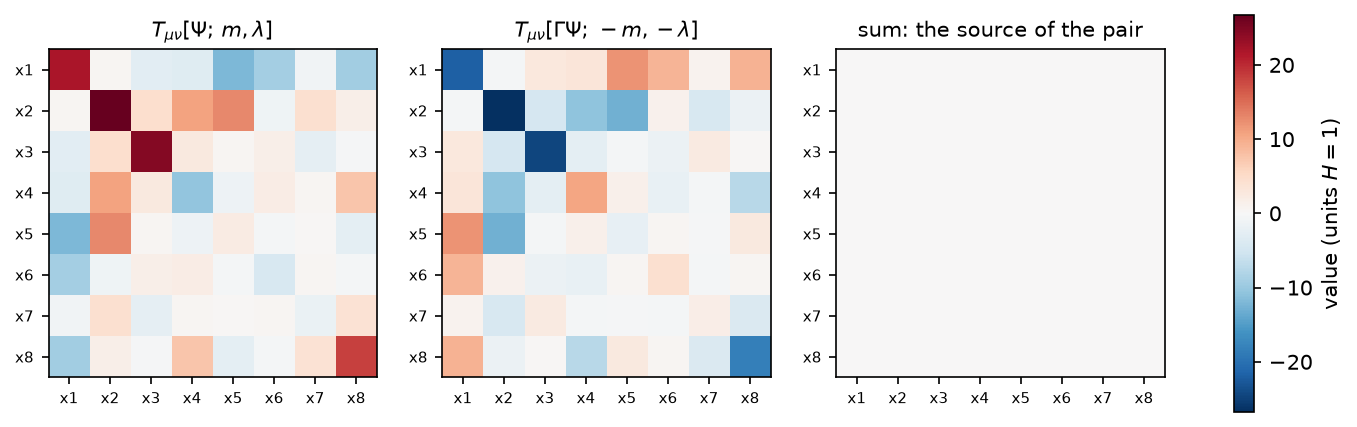

Figure 20a.1 saved as Revision/textbook/figures/20a_1_t1_pair_tensor.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12.0, 4.3))
panels = ((one["T"], "$T_{\\mu\\nu}[\\Psi;\\,m,\\lambda]$"),
          (partner["T"], "$T_{\\mu\\nu}[\\Gamma\\Psi;\\,-m,-\\lambda]$"),
          (one["T"] + partner["T"], "sum: the source of the pair"))
for ax, (values, title) in zip(axes, panels):
    image = ax.imshow(values, cmap="RdBu_r", vmin=-scale, vmax=scale)
    ax.set_xticks(range(8))
    ax.set_xticklabels(NAMES, fontsize=7)
    ax.set_yticks(range(8))
    ax.set_yticklabels(NAMES, fontsize=7)
    ax.grid(False)  # no grid lines across the coloured squares
    ax.set_title(title, fontsize=10)
fig.colorbar(image, ax=list(axes), shrink=0.8, label="value (units $H = 1$)")
save_figure(fig, "t1_pair_tensor",
            "The energy-momentum tensor $T_{\\mu\\nu}$ (rows $\\mu$, columns $\\nu$, "
            "$x_1$ to $x_8$) of an arbitrary configuration $\\Psi$ of "
            "dirac16complex00 with $m = 2$, $\\lambda = 1/2$ at one point of the "
            "author's metric ($z = 0.6$, $a_4 = 0.5$, $a_4' = H$, units $H = 1$; "
            "colour scale red positive, blue negative), of its T1 partner "
            "$\\Gamma\\Psi$ with $(-m, -\\lambda)$, and of their sum. The middle "
            "table is the left one with every sign reversed, so the sum is white: "
            "all 64 components of the source of the pair are zero, as theorem T1 "
            "says, although the configuration is not even a solution.")

## 9. Along the hidden direction: the T1 partner and the T2 mirror copy

T1 holds at EVERY point. To see it along a line, the next cell keeps the same
values and first derivatives of the configuration at every $z$, except that it
sets the derivative along $x_8$ to zero (otherwise the term
$\tan z\,\gamma^{(x_8)}\partial_8\Psi$ grows without bound at the brane, where
$g_{88} = \cot^2z$ vanishes). The geometry changes with $z$ through
$\sin^{1/6}z$ and $\cot z$. It evaluates three objects:

- the configuration $\Psi$ with $(m, \lambda)$ on the patch, $0 < z < \pi/2$;
- its T1 partner $\Gamma\Psi$ with $(-m, -\lambda)$ at the same points;
- its T2 mirror copy: by theorem T2 (with $m$ replaced by $-m$), the field
  $\Psi'(\pi - z) = \gamma^{(x_8)}\Psi(z)$ on the mirror patch solves the
  $(-m, \lambda)$ equations if and only if $\Psi$ solves the $(m, \lambda)$
  equations. Its derivatives are $\gamma^{(x_8)}$ times those of $\Psi$, with the
  $x_8$ derivative reversed (here zero).

It computes the energy density $\rho = -T_{x_4x_4}$ and the charge density
$J^{x_4}$ of each, and checks: the T1 partner has $-\rho$ and $-J^{x_4}$; the
mirror copy has, at the mirror point $\pi - z$, the SAME $\rho$ and the SAME
$J^{x_4}$.

In [9]:
flat_dpsi = [row.copy() for row in dpsi]
flat_dpsi[7] = np.zeros(16)  # no derivative along x8
z_patch = np.linspace(0.05, np.pi / 2 - 0.02, 160)  # points of the patch
rho, charge = {"one": [], "T1": [], "T2": []}, {"one": [], "T1": [], "T2": []}
for z_value in z_patch:
    here = geometry_at(1, z_value, A4_0, 1.0)
    there = geometry_at(-1, np.pi - z_value, A4_0, 1.0)  # the mirror point
    results = {
        "one": bilinears(here, psi, flat_dpsi, M0, LAM0),
        "T1": bilinears(here, Gamma_num @ psi, [Gamma_num @ r for r in flat_dpsi],
                        -M0, -LAM0),
        "T2": bilinears(there, gamma_num[7] @ psi,
                        [gamma_num[7] @ r for r in flat_dpsi], -M0, LAM0),
    }
    for key, result in results.items():
        rho[key].append(-result["T"][3, 3])  # rho = -T_x4x4
        charge[key].append(result["J"][3])  # J^x4
rho = {key: np.array(values) for key, values in rho.items()}
charge = {key: np.array(values) for key, values in charge.items()}
size = max(np.abs(rho["one"]).max(), np.abs(charge["one"]).max())
check(np.abs(rho["T1"] + rho["one"]).max() < 1e-12 * size
      and np.abs(charge["T1"] + charge["one"]).max() < 1e-12 * size,
      "along z: the T1 partner has -rho and -J^x4 at every point")
check(np.abs(rho["T2"] - rho["one"]).max() < 1e-10 * size
      and np.abs(charge["T2"] - charge["one"]).max() < 1e-10 * size,
      "along z: the T2 copy has the same rho and J^x4 at the mirror point")

PASS along z: the T1 partner has -rho and -J^x4 at every point
PASS along z: the T2 copy has the same rho and J^x4 at the mirror point


The next cell draws the two densities across the whole interval $0 < z < \pi$:
on the left of the brane the configuration and its T1 partner, on the right the
T2 mirror copy (plotted at its own points $\pi - z$).

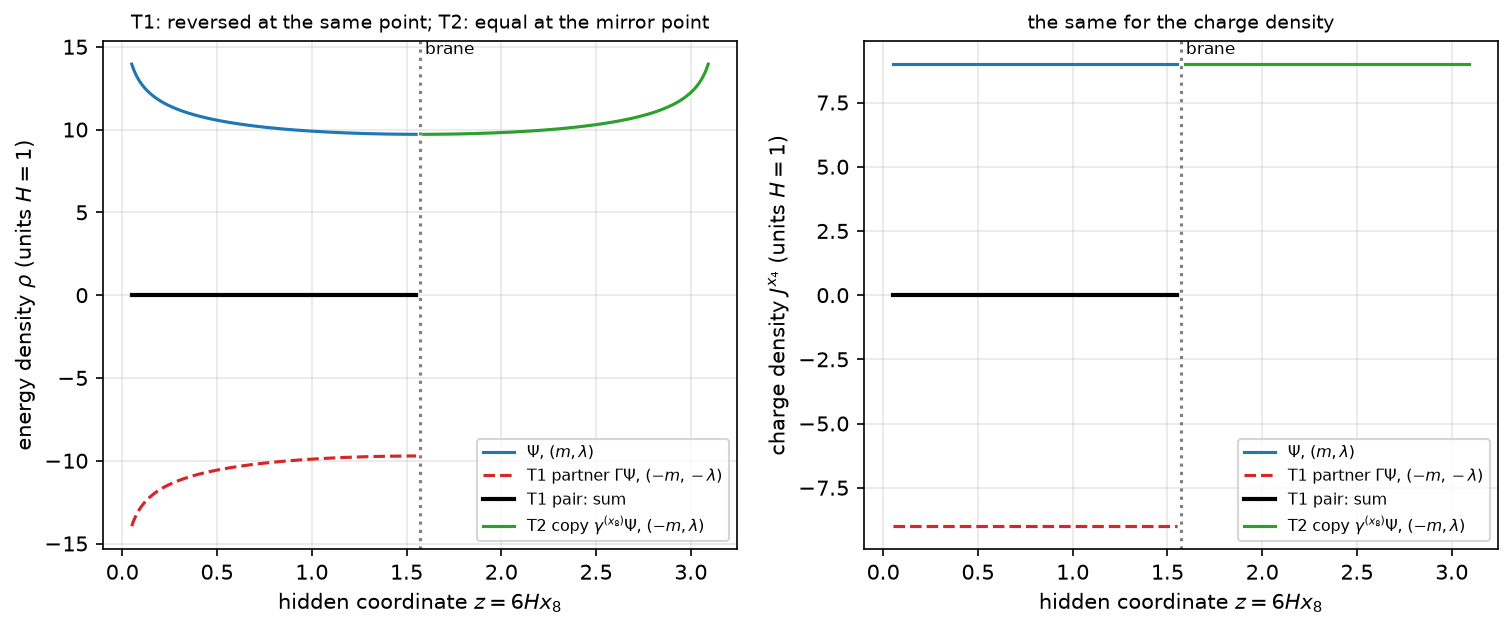

Figure 20a.2 saved as Revision/textbook/figures/20a_2_pair_profiles.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.4))
for ax, data, label in ((axes[0], rho, "energy density $\\rho$"),
                        (axes[1], charge, "charge density $J^{x_4}$")):
    ax.plot(z_patch, data["one"], color="tab:blue", label="$\\Psi$, $(m, \\lambda)$")
    ax.plot(z_patch, data["T1"], "--", color="tab:red",
            label="T1 partner $\\Gamma\\Psi$, $(-m, -\\lambda)$")
    ax.plot(z_patch, data["one"] + data["T1"], color="black", linewidth=2.0,
            label="T1 pair: sum")
    ax.plot(np.pi - z_patch, data["T2"], color="tab:green",
            label="T2 copy $\\gamma^{(x_8)}\\Psi$, $(-m, \\lambda)$")
    ax.axvline(np.pi / 2, color="grey", linestyle=":", linewidth=1.5)
    ax.text(np.pi / 2, ax.get_ylim()[1], " brane", va="top", fontsize=8)
    ax.set_xlabel("hidden coordinate $z = 6Hx_8$")
    ax.set_ylabel(label + " (units $H = 1$)")
    ax.legend(fontsize=7.5, loc="best")
axes[0].set_title("T1: reversed at the same point; T2: equal at the mirror point",
                  fontsize=9)
axes[1].set_title("the same for the charge density", fontsize=9)
save_figure(fig, "pair_profiles",
            "Left: the energy density $\\rho = -T_{x_4x_4}$, right: the charge "
            "density $J^{x_4} = \\Psi^\\dagger B\\Psi$, as functions of the hidden "
            "coordinate $z$ (horizontal, from 0 to $\\pi$; the brane $z = \\pi/2$ "
            "dotted; units $H = 1$), for an arbitrary configuration $\\Psi$ of "
            "dirac16complex00 with $(m, \\lambda) = (2, 1/2)$ on the patch (blue), "
            "its T1 partner $\\Gamma\\Psi$ with $(-m, -\\lambda)$ (red dashed) and "
            "their sum (black, zero everywhere), and the T2 mirror copy "
            "$\\gamma^{(x_8)}\\Psi$ with $(-m, \\lambda)$ on the mirror patch "
            "(green). The T1 partner is the blue curve reflected in the horizontal "
            "axis; the T2 copy is the blue curve reflected in the vertical line of "
            "the brane, with the same sign: T1 pairs cancel, T2 pairs add.")

## 10. The T2 mirror pair does not cancel

Theorem T2 in the author's field says more than equal energy densities: at the
mirror point the whole tensor of the copy is the pulled-back tensor,
$T_{\mu\nu}[\Psi'](\pi - z) = (R_8\,T[\Psi](z)\,R_8)_{\mu\nu}$ with $R_8 =
\mathrm{diag}(1,1,1,1,1,1,1,-1)$: the components with exactly one index $x_8$
change sign (the direction $x_8$ is reversed by the mirror), all others are EQUAL.
Likewise $J'^\mu = (R_8)^\mu{}_\nu J^\nu$, $S' = -S$, and the field-equation
residuals obey $E_{-m,\lambda}[\Psi'] = -\gamma^{(x_8)}E_{m,\lambda}[\Psi]$. The
next cell checks all of this at the point $z = 0.6$ with the full configuration
(including its derivative along $x_8$, which the mirror reverses) and draws the
three tables.

PASS T2 copy: T' = R8 T R8 at the mirror point (64 components)
     reproduces Revision/pairing/reports/python-pairing.json, check
    T2.metric.commuting.emt
PASS T2 copy: J' = R8 J (the charge density is unchanged)
     reproduces Revision/pairing/reports/python-pairing.json, check
    T2.metric.commuting.current
PASS T2 copy: S' = -S
     reproduces Revision/pairing/reports/python-pairing.json, check
    T2.metric.commuting.S_odd
PASS T2 copy: E_(-m,lambda)[Psi'] = -gamma^(x8) E_(m,lambda)[Psi]
     reproduces Revision/pairing/reports/python-pairing.json, check
    T2.metric.commuting.euler_lagrange_map
PASS T2 pair: the tensors do NOT cancel
     reproduces Revision/pairing/reports/wolfram-pairing.json, check
    T2_mirror_energy_momentum_and_current_commuting


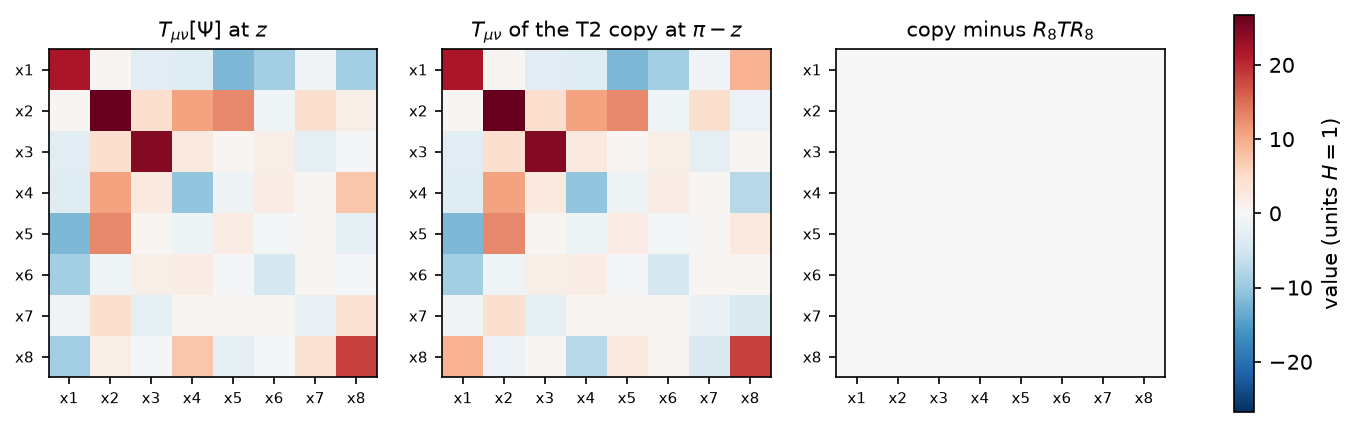

Figure 20a.3 saved as Revision/textbook/figures/20a_3_t2_mirror_tensor.png


In [11]:
R8 = np.array([1, 1, 1, 1, 1, 1, 1, -1.0])  # the reflection of the x8 direction
mirror_dpsi = [R8[mu] * (gamma_num[7] @ dpsi[mu]) for mu in range(8)]
copy = bilinears(geometry_at(-1, np.pi - Z0, A4_0, 1.0), gamma_num[7] @ psi,
                 mirror_dpsi, -M0, LAM0)  # the T2 copy at the mirror point
pulled_back = np.outer(R8, R8) * one["T"]  # R8 T R8
reproduces(np.abs(copy["T"] - pulled_back).max() < 1e-10 * scale,
           "T2 copy: T' = R8 T R8 at the mirror point (64 components)",
           PAIR_PY, "T2.metric.commuting.emt")
reproduces(np.abs(copy["J"] - R8 * one["J"]).max() < 1e-10 * scale,
           "T2 copy: J' = R8 J (the charge density is unchanged)",
           PAIR_PY, "T2.metric.commuting.current")
reproduces(abs(copy["S"] + one["S"]) < 1e-10 * scale, "T2 copy: S' = -S",
           PAIR_PY, "T2.metric.commuting.S_odd")
reproduces(np.abs(copy["E"] + gamma_num[7] @ one["E"]).max() < 1e-10 * scale,
           "T2 copy: E_(-m,lambda)[Psi'] = -gamma^(x8) E_(m,lambda)[Psi]",
           PAIR_PY, "T2.metric.commuting.euler_lagrange_map")
reproduces(np.abs(copy["T"] + one["T"]).max() > 0.1 * scale,
           "T2 pair: the tensors do NOT cancel",
           PAIR_WL, "T2_mirror_energy_momentum_and_current_commuting")
fig, axes = plt.subplots(1, 3, figsize=(12.0, 4.3))
panels = ((one["T"], "$T_{\\mu\\nu}[\\Psi]$ at $z$"),
          (copy["T"], "$T_{\\mu\\nu}$ of the T2 copy at $\\pi - z$"),
          (copy["T"] - pulled_back, "copy minus $R_8TR_8$"))
for ax, (values, title) in zip(axes, panels):
    image = ax.imshow(values, cmap="RdBu_r", vmin=-scale, vmax=scale)
    ax.set_xticks(range(8))
    ax.set_xticklabels(NAMES, fontsize=7)
    ax.set_yticks(range(8))
    ax.set_yticklabels(NAMES, fontsize=7)
    ax.grid(False)
    ax.set_title(title, fontsize=10)
fig.colorbar(image, ax=list(axes), shrink=0.8, label="value (units $H = 1$)")
save_figure(fig, "t2_mirror_tensor",
            "Left: the energy-momentum tensor $T_{\\mu\\nu}$ of the configuration "
            "$\\Psi$ with $(m, \\lambda) = (2, 1/2)$ at $z = 0.6$ on the patch "
            "(rows and columns $x_1$ to $x_8$, units $H = 1$). Middle: the tensor "
            "of its T2 mirror copy $\\gamma^{(x_8)}\\Psi$ with $(-m, \\lambda)$ at "
            "the mirror point $z = \\pi - 0.6$. The two tables are equal except "
            "for the last row and column, whose off-diagonal entries (one index "
            "$x_8$) change sign. Right: the copy minus $R_8TR_8$, zero everywhere. "
            "Unlike the T1 partner, the mirror copy carries the SAME energy, so "
            "the T2 pair has twice the source of one member.")

## 11. The pair as the only source: Einstein's vacuum equations

By lines 1 and 2 of the proof (checked in sections 8 and 9) a T1 pair as the only
source gives $T = 0$, and the field equations of gravity become the vacuum
equations. The next cell reads the four independent components of the Einstein
tensor $G = E_{(1)}$ from the record `a4-equations.json` (the symbols `ad1` and
`ad2` there are $a_4'$ and $a_4''$), forms the vacuum equations
$G^\mu{}_\mu + \Lambda = 0$ for $\mu = x_1, x_4, x_5, x_8$ (the other diagonal
components repeat these, the off-diagonal ones are identically zero), and lets
sympy solve them for $a_4'$, $a_4''$ and $\Lambda$ WITHOUT assuming that $a_4'$
is real. It also forms the two combinations of the proof: the $x_4$ equation minus
the $x_8$ equation, and their sum.

In [12]:
record = read_json(A4_RECORD)
ad1, ad2 = sp.symbols("ad1 ad2")  # a4' and a4'' (complex allowed)
Lam = sp.symbols("Lambda")  # the cosmological constant
alpha2, alpha3, A = sp.symbols("alpha2 alpha3 A", real=True)
KEYS = ["x1x1", "x4x4", "x5x5", "x8x8"]  # the independent diagonal components


def lovelock(order, key):
    """The component key of E_(order) from the record, as a sympy expression."""
    text = record["lovelockTensors"][f"E{order}"][key]["input"].replace("^", "**")
    return sp.sympify(text, locals={"ad1": ad1, "ad2": ad2, "H": H})


G = {key: lovelock(1, key) for key in KEYS}  # the Einstein tensor
for key in KEYS:
    say(f"G^{key[:2]}_{key[2:]} = {G[key]}")
vacuum = [G[key] + Lam for key in KEYS]  # zero source
solutions = sp.solve(vacuum, [ad1, ad2, Lam], dict=True)
say(f"all solutions of the vacuum equations: {solutions}")
found = {(s[ad1], s[ad2], s[Lam]) for s in solutions}
reproduces(found == {(sp.I * H, 0, -18 * H ** 2), (-sp.I * H, 0, -18 * H ** 2)},
           "the only solutions have a4' = +i H or -i H: none is real",
           LEAD_EGB, "no_vacuum_for_H_positive")
difference = sp.expand(vacuum[1] - vacuum[3])  # x4 equation minus x8 equation
total = sp.expand(vacuum[1] + vacuum[3])  # x4 equation plus x8 equation
report("x4 equation minus x8 equation", difference)
report("x4 equation plus x8 equation", total)
reproduces(difference == 6 * ad1 ** 2 + 6 * H ** 2
           and total == 36 * H ** 2 + 2 * Lam,
           "6 a4'^2 + 6 H^2 = 0 and 36 H^2 + 2 Lambda = 0 (record's lines)",
           A4_WL, "einstein_no_vacuum_solution")
a_real = sp.symbols("a_real", real=True)  # a real value of a4'
reproduces(sp.solve(difference.subs(ad1, a_real), a_real) == [],
           "for real a4' the difference 6 a4'^2 + 6 H^2 never vanishes",
           A4_PY, "einstein_no_vacuum")

G^x1_x1 = 15*H**2 - 3*ad1**2 + ad2
G^x4_x4 = 21*H**2 + 3*ad1**2
G^x5_x5 = 15*H**2 - 3*ad1**2 - ad2
G^x8_x8 = 15*H**2 - 3*ad1**2
all solutions of the vacuum equations: [{Lambda: -18*H**2, ad1: -I*H, ad2: 0}, {Lambda:
    -18*H**2, ad1: I*H, ad2: 0}]
PASS the only solutions have a4' = +i H or -i H: none is real
     reproduces Revision/lead_checks/reports/einstein-gauss-bonnet-a4.json, check
    no_vacuum_for_H_positive
RESULT x4 equation minus x8 equation = 6*H**2 + 6*ad1**2
RESULT x4 equation plus x8 equation = 36*H**2 + 2*Lambda
PASS 6 a4'^2 + 6 H^2 = 0 and 36 H^2 + 2 Lambda = 0 (record's lines)
     reproduces Revision/field_equations_a4/reports/wolfram-a4-report.json, check
    einstein_no_vacuum_solution
PASS for real a4' the difference 6 a4'^2 + 6 H^2 never vanishes
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    einstein_no_vacuum


The next cell draws the two vacuum conditions as curves in the plane of $a_4'/H$
(horizontal) and $\Lambda/H^2$ (vertical): the $x_4$ equation holds on the
parabola $\Lambda = -(3a_4'^2 + 21H^2)$, which opens downwards, the $x_8$ equation
on $\Lambda = 3a_4'^2 - 15H^2$, which opens upwards. A vacuum would be a point on
both. The vertical distance between them is $6a_4'^2 + 6H^2 \geq 6H^2$: they
never meet. At the author's history $a_4' = H$ the gap is $12H^2$.

PASS the two curves stay 6 H^2 apart or more


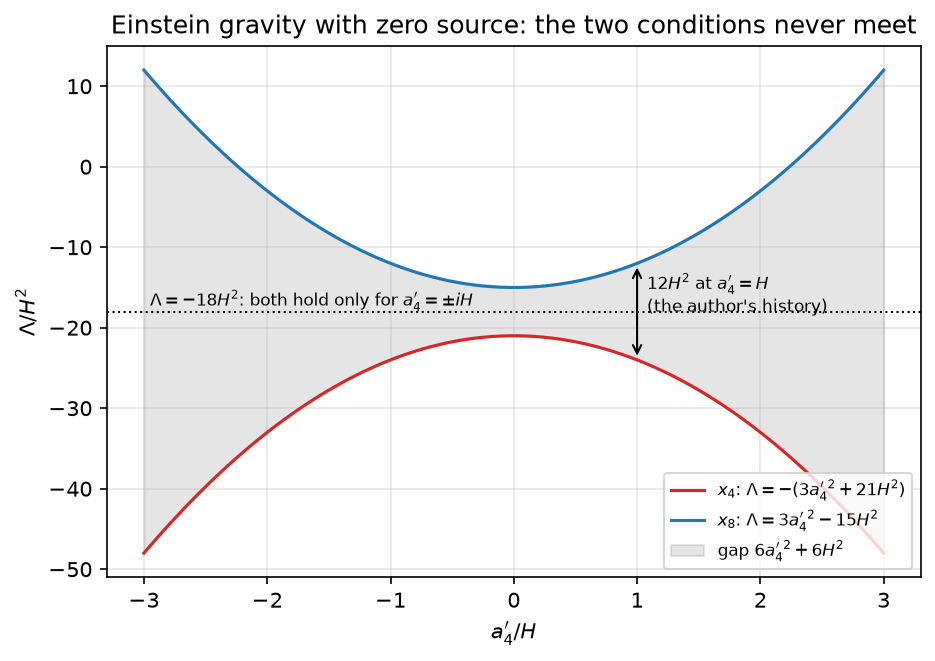

Figure 20a.4 saved as Revision/textbook/figures/20a_4_einstein_vacuum_parabolas.png


In [13]:
slopes = np.linspace(-3.0, 3.0, 601)  # a4'/H
lower = -(3 * slopes ** 2 + 21)  # Lambda/H^2 where the x4 equation holds
upper = 3 * slopes ** 2 - 15  # Lambda/H^2 where the x8 equation holds
check(np.min(upper - lower) >= 6.0 - 1e-12, "the two curves stay 6 H^2 apart or more")
fig, ax = plt.subplots(figsize=(7.0, 4.6))
ax.plot(slopes, lower, color="tab:red", label="$x_4$: $\\Lambda = -(3a_4'^2 + 21H^2)$")
ax.plot(slopes, upper, color="tab:blue", label="$x_8$: $\\Lambda = 3a_4'^2 - 15H^2$")
ax.fill_between(slopes, lower, upper, color="grey", alpha=0.2,
                label="gap $6a_4'^2 + 6H^2$")
ax.annotate("", xy=(1.0, -12.0), xytext=(1.0, -24.0),
            arrowprops={"arrowstyle": "<->", "color": "black"})
ax.text(1.08, -18.0, "$12H^2$ at $a_4' = H$\n(the author's history)", fontsize=8)
ax.axhline(-18.0, color="black", linestyle=":", linewidth=1.0)
ax.text(-2.95, -17.3, "$\\Lambda = -18H^2$: both hold only for $a_4' = \\pm iH$",
        fontsize=8)
ax.set_xlabel("$a_4'/H$")
ax.set_ylabel("$\\Lambda/H^2$")
ax.set_title("Einstein gravity with zero source: the two conditions never meet")
ax.legend(fontsize=8, loc="lower right")
save_figure(fig, "einstein_vacuum_parabolas",
            "The vacuum equations of Einstein gravity for the author's metric, the "
            "situation of a T1 pair as the only source: horizontal axis the rate "
            "$a_4'/H$, vertical axis the cosmological constant $\\Lambda/H^2$. The "
            "$x_4$ component holds on the red parabola, the $x_8$ component on the "
            "blue one; a vacuum solution would lie on both. They are separated by "
            "$6a_4'^2 + 6H^2 \\geq 6H^2$ (grey band), $12H^2$ at the author's "
            "deflating history $a_4' = H$, so no real rate and no $\\Lambda$ solve "
            "both; the only solutions, $a_4' = \\pm iH$ with $\\Lambda = -18H^2$ "
            "(dotted line), are not real.")

## 12. What the geometry requires and what a pair supplies

Line 5 of the proof is a statement about the source. Write the $x_4$ and $x_8$
equations with a source: $\sum_k\alpha_kE_{(k)}{}^{x_4}{}_{x_4} + \Lambda =
-\kappa\rho$ and $\sum_k\alpha_kE_{(k)}{}^{x_8}{}_{x_8} + \Lambda = \kappa p_8$
(the record's sign convention). Subtracting the first from the second removes
$\Lambda$ and gives the **null combination** the geometry REQUIRES of any source:

$$\kappa(\rho + p_8) = -\sum_k\alpha_k\big(E_{(k)}{}^{x_4}{}_{x_4} -
E_{(k)}{}^{x_8}{}_{x_8}\big).$$

In Einstein gravity this is $-6(a_4'^2 + H^2) < 0$ (the record's
`einstein_null_energy_x8`). For the linear member $a_4' = AH$ the record writes
the right-hand side as $-6(A^2 + 1)H^2V$ with the **vacuum factor**

$$V = \alpha_1 - 40\alpha_2H^2 - 8A^2\alpha_2H^2 + 360\alpha_3H^4 +
144A^2\alpha_3H^4 + 72A^4\alpha_3H^4 .$$

A T1 pair SUPPLIES $\rho + p_8 = 0$; so it can be the only source only where the
requirement is zero, that is where $V = 0$. The next cell reads the record's null
combination and vacuum factor, checks both against the Lovelock components, and
checks the Einstein case.

In [14]:
couplings = {"alpha1": 1, "alpha2": alpha2, "alpha3": alpha3, "H": H, "ad1": ad1,
             "ad2": ad2, "AA": A}  # alpha1 = 1 throughout
null_text = record["generalSource"]["nullCombinations"]["kappa(rho+p8)"]["input"]
null_required = sp.sympify(null_text.replace("^", "**"), locals=couplings)
V_text = record["linearMember"]["vacuumFactor"]["input"]
V = sp.sympify(V_text.replace("^", "**"), locals=couplings)
lovelock_sum = {key: lovelock(1, key) + alpha2 * lovelock(2, key)
                + alpha3 * lovelock(3, key) for key in KEYS}
own_null = -(lovelock_sum["x4x4"] - lovelock_sum["x8x8"])
check(sp.expand(own_null - null_required) == 0,
      "the null combination of the record equals -(E^x4_x4 - E^x8_x8)")
linear = {ad1: A * H, ad2: 0}  # the linear member a4 = A H x4 + a0
reproduces(sp.expand(own_null.subs(linear) + 6 * (A ** 2 + 1) * H ** 2 * V) == 0,
           "linear member: kappa (rho + p8) = -6 (A^2 + 1) H^2 V",
           A4_WL, "linear_member_vacuum_factor")
reproduces(sp.expand(V.subs({alpha2: 0, alpha3: 0})) == 1
           and sp.expand(null_required.subs({alpha2: 0, alpha3: 0})
                         + 6 * ad1 ** 2 + 6 * H ** 2) == 0,
           "Einstein: V = 1 and kappa (rho + p8) = -6 (a4'^2 + H^2)",
           A4_PY, "einstein_null_energy_x8")
reproduces(sp.expand(null_required.subs({alpha2: 0, alpha3: 0})
                     + 6 * ad1 ** 2 + 6 * H ** 2) == 0,
           "the same null combination from the lead's independent Einstein tensor",
           LEAD_EGB, "einstein_null_energy")

PASS the null combination of the record equals -(E^x4_x4 - E^x8_x8)
PASS linear member: kappa (rho + p8) = -6 (A^2 + 1) H^2 V
     reproduces Revision/field_equations_a4/reports/wolfram-a4-report.json, check
    linear_member_vacuum_factor
PASS Einstein: V = 1 and kappa (rho + p8) = -6 (a4'^2 + H^2)
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    einstein_null_energy_x8
PASS the same null combination from the lead's independent Einstein tensor
     reproduces Revision/lead_checks/reports/einstein-gauss-bonnet-a4.json, check
    einstein_null_energy


The next cell draws the required null combination $\kappa(\rho + p_8)/H^2$ for the
linear member as a function of the slope $A$, in Einstein gravity and in two
Einstein-Gauss-Bonnet theories ($\alpha_3 = 0$; $\alpha_2H^2 = 1/48$ and $1/40$).
The black line is what a T1 pair supplies: zero. In Einstein gravity the curve
stays at or below $-6H^2$; in the Gauss-Bonnet theories it crosses zero once.

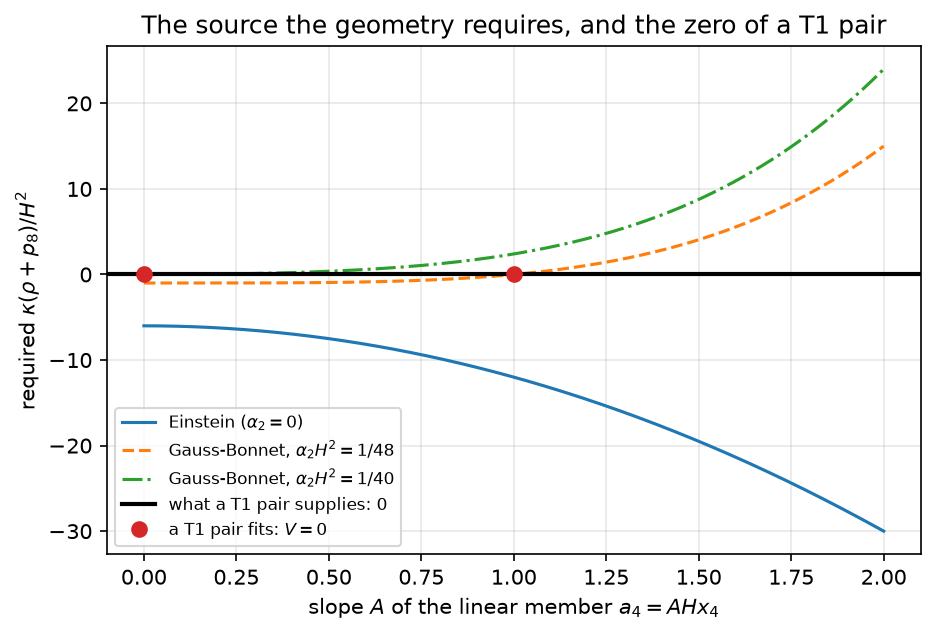

Figure 20a.5 saved as Revision/textbook/figures/20a_5_null_combination.png


In [15]:
A_axis = np.linspace(0.0, 2.0, 401)
V_numeric = sp.lambdify((A, alpha2, alpha3), V.subs(H, 1), "numpy")
fig, ax = plt.subplots(figsize=(7.0, 4.4))
for x2, style, label in ((0.0, "-", "Einstein ($\\alpha_2 = 0$)"),
                         (1 / 48, "--", "Gauss-Bonnet, $\\alpha_2H^2 = 1/48$"),
                         (1 / 40, "-.", "Gauss-Bonnet, $\\alpha_2H^2 = 1/40$")):
    required = -6 * (A_axis ** 2 + 1) * V_numeric(A_axis, x2, 0.0)
    ax.plot(A_axis, required, style, label=label)
ax.axhline(0.0, color="black", linewidth=2.0, label="what a T1 pair supplies: 0")
ax.plot([1.0, 0.0], [0.0, 0.0], "o", color="tab:red", markersize=7,
        label="a T1 pair fits: $V = 0$")
ax.set_xlabel("slope $A$ of the linear member $a_4 = AHx_4$")
ax.set_ylabel("required $\\kappa(\\rho + p_8)/H^2$")
ax.set_title("The source the geometry requires, and the zero of a T1 pair")
ax.legend(fontsize=8, loc="lower left")
save_figure(fig, "null_combination",
            "The null combination $\\kappa(\\rho + p_8)$ (energy density plus the "
            "pressure along $x_8$, times the gravitational coupling; vertical, "
            "units $H^2$) that the field equations require of ANY source of the "
            "linear member $a_4 = AHx_4$, against its slope $A$ (horizontal), for "
            "Einstein gravity (solid) and two Einstein-Gauss-Bonnet theories with "
            "$\\alpha_2H^2 = 1/48$ (dashed) and $1/40$ (dash-dotted). A T1 pair "
            "supplies zero (black line). In Einstein gravity the requirement is "
            "$-6(A^2 + 1)H^2 < 0$ for every $A$, so a T1 pair can never be the "
            "only source; with the Gauss-Bonnet term the requirement vanishes at "
            "one slope (red dots: $A = 1$, the author's history, for "
            "$\\alpha_2H^2 = 1/48$, and $A = 0$ for $1/40$).")

## 13. Einstein-Gauss-Bonnet gravity: when a zero source is allowed

Part (b) of C1. With $\alpha_1 = 1$ and $\alpha_3 = 0$ the vacuum factor is
$V = 1 - 40\alpha_2H^2 - 8A^2\alpha_2H^2 = 1 - 8\alpha_2H^2(A^2 + 5)$. Setting
$V = 0$ and solving for $A^2$, line by line: add $8\alpha_2H^2(A^2 + 5)$ to both
sides, $8\alpha_2H^2(A^2 + 5) = 1$; divide by $8\alpha_2H^2$ (not zero),
$A^2 + 5 = 1/(8\alpha_2H^2)$; subtract 5,

$$A^2 = \frac{1 - 40\alpha_2H^2}{8\alpha_2H^2},$$

real and not negative exactly when $0 < \alpha_2H^2 \leq 1/40$. Then the $x_4$
equation fixes $\Lambda = -\sum_k\alpha_kE_{(k)}{}^{x_4}{}_{x_4}$. For the author's
history $A = 1$: $8\alpha_2H^2 \cdot 6 = 1$, so $\alpha_2H^2 = 1/48$. The next cell
checks the formula and then checks EXACTLY that with $\alpha_2 = 1/(48H^2)$ and
the resulting $\Lambda$ all four independent components of the vacuum equations
vanish for $a_4 = Hx_4$. In that theory a T1 pair CAN be the only source of the
author's deflating history; C1(a) is a statement about Einstein gravity.

In [16]:
V_gb = sp.expand(V.subs(alpha3, 0))
A_squared = sp.solve(V_gb, A ** 2)[0]
reproduces(sp.simplify(A_squared - (1 - 40 * alpha2 * H ** 2)
                       / (8 * alpha2 * H ** 2)) == 0,
           "Gauss-Bonnet vacuum: A^2 = (1 - 40 alpha2 H^2)/(8 alpha2 H^2)",
           A4_WL, "einstein_gauss_bonnet_vacuum_linear")
x2_author = sp.solve(A_squared.subs(H, 1) - 1, alpha2)[0]  # A = 1, H = 1
report("alpha2 H^2 for a vacuum with A = 1", x2_author)
gauss_bonnet = {key: (lovelock(1, key) + alpha2 * lovelock(2, key))
                .subs({ad1: H, ad2: 0, alpha2: x2_author / H ** 2})
                for key in KEYS}
Lam_author = sp.simplify(-gauss_bonnet["x4x4"])  # Lambda from the x4 equation
report("Lambda of that vacuum", Lam_author)
reproduces(x2_author == sp.Rational(1, 48) and Lam_author == -12 * H ** 2
           and all(sp.simplify(gauss_bonnet[key] + Lam_author) == 0 for key in KEYS),
           "a4 = H x4 solves the Gauss-Bonnet vacuum equations exactly",
           A4_PY, "einstein_gauss_bonnet_vacuum_linear")
zero_off = all(record["lovelockTensors"][f"E{k}"][key]["input"] == "0"
               for k in (1, 2, 3) for key in ("x4x8", "x8x4"))
check(zero_off, "the mixed components x4x8 and x8x4 of E_(1..3) are 0 in the record")
Lam_curve = sp.simplify(-(lovelock(1, "x4x4") + alpha2 * lovelock(2, "x4x4"))
                        .subs({ad1: A * H, ad2: 0}).subs(A ** 2, A_squared))
say(f"Lambda along the vacuum curve: {sp.factor(Lam_curve)}")

PASS Gauss-Bonnet vacuum: A^2 = (1 - 40 alpha2 H^2)/(8 alpha2 H^2)
     reproduces Revision/field_equations_a4/reports/wolfram-a4-report.json, check
    einstein_gauss_bonnet_vacuum_linear
RESULT alpha2 H^2 for a vacuum with A = 1 = 1/48
RESULT Lambda of that vacuum = -12*H**2
PASS a4 = H x4 solves the Gauss-Bonnet vacuum equations exactly
     reproduces Revision/field_equations_a4/reports/python-a4-report.json, check
    einstein_gauss_bonnet_vacuum_linear
PASS the mixed components x4x8 and x8x4 of E_(1..3) are 0 in the record
Lambda along the vacuum curve: 3*(3840*H**4*alpha2**2 - 192*H**2*alpha2 + 1)/(16*alpha2)


The next cell draws the Gauss-Bonnet vacua: on the left the slope
$A = \sqrt{(1 - 40\alpha_2H^2)/(8\alpha_2H^2)}$ against $\alpha_2H^2$, on the right
the cosmological constant $\Lambda$ that each vacuum needs. As $\alpha_2 \to 0$
(Einstein gravity) the slope grows without bound: Einstein gravity has no vacuum.

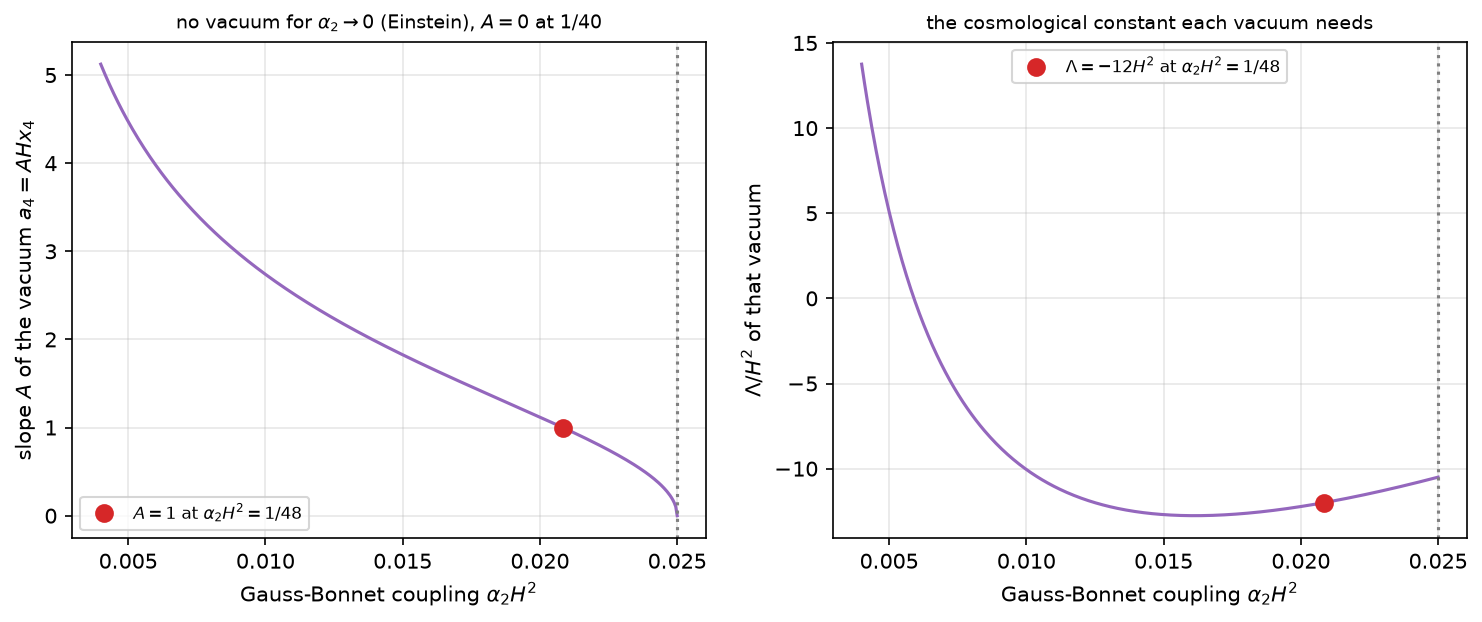

Figure 20a.6 saved as Revision/textbook/figures/20a_6_gauss_bonnet_vacuum.png


In [17]:
x_axis = np.linspace(0.004, 1 / 40, 400)  # alpha2 H^2
A_curve = np.sqrt((1 - 40 * x_axis) / (8 * x_axis))
Lam_numeric = sp.lambdify(alpha2, Lam_curve.subs(H, 1), "numpy")
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.3))
axes[0].plot(x_axis, A_curve, color="tab:purple")
axes[0].plot([1 / 48], [1.0], "o", color="tab:red", markersize=8,
             label="$A = 1$ at $\\alpha_2H^2 = 1/48$")
axes[0].set_ylabel("slope $A$ of the vacuum $a_4 = AHx_4$")
axes[1].plot(x_axis, Lam_numeric(x_axis), color="tab:purple")
axes[1].plot([1 / 48], [-12.0], "o", color="tab:red", markersize=8,
             label="$\\Lambda = -12H^2$ at $\\alpha_2H^2 = 1/48$")
axes[1].set_ylabel("$\\Lambda/H^2$ of that vacuum")
for ax in axes:
    ax.set_xlabel("Gauss-Bonnet coupling $\\alpha_2H^2$")
    ax.axvline(1 / 40, color="grey", linestyle=":")
    ax.legend(fontsize=8)
axes[0].set_title("no vacuum for $\\alpha_2 \\to 0$ (Einstein), $A = 0$ at $1/40$",
                  fontsize=9)
axes[1].set_title("the cosmological constant each vacuum needs", fontsize=9)
save_figure(fig, "gauss_bonnet_vacuum",
            "The vacua of Einstein-Gauss-Bonnet gravity ($\\alpha_1 = 1$, "
            "$\\alpha_3 = 0$) among the linear members $a_4 = AHx_4$ of the author's "
            "metric: the geometries in which a T1 pair could be the only source. "
            "Left: the slope $A = \\sqrt{(1 - 40\\alpha_2H^2)/(8\\alpha_2H^2)}$ "
            "against the coupling $\\alpha_2H^2$ (horizontal, up to the dotted "
            "limit $1/40$ where $A = 0$); it grows without bound as "
            "$\\alpha_2 \\to 0$, the Einstein limit, which has no vacuum. Right: "
            "the cosmological constant $\\Lambda/H^2$ that the same vacuum needs. "
            "Red dots: the author's deflating history $A = 1$ is a vacuum for "
            "$\\alpha_2H^2 = 1/48$ and $\\Lambda = -12H^2$ (checked exactly).")

## 14. Third order: one straight line of vacua per slope

With the third Lovelock coupling as well, $V = 0$ reads
$1 - 40x - 8A^2x + 360y + 144A^2y + 72A^4y = 0$ in the variables
$x = \alpha_2H^2$ and $y = \alpha_3H^4$. For a FIXED slope $A$ this is linear in
$x$ and $y$: solving for $y$,

$$y = \frac{(8A^2 + 40)x - 1}{72A^4 + 144A^2 + 360},$$

a straight line in the plane of the two couplings. Einstein gravity is the origin
$x = y = 0$, where $V = 1$: it lies on none of the lines. The next cell checks the
line formula with sympy and draws the lines for several slopes; the point
$(1/48, 0)$ of section 13 lies on the line $A = 1$.

PASS for fixed A the vacua form a straight line
PASS Einstein gravity (origin) has V = 1


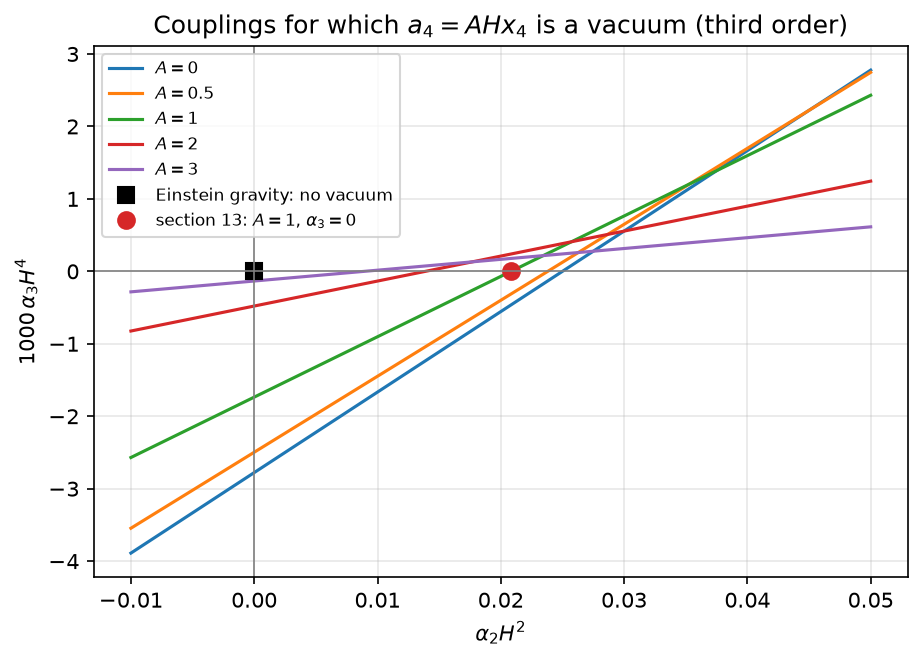

Figure 20a.7 saved as Revision/textbook/figures/20a_7_third_order_vacua.png


In [18]:
y_line = sp.solve(V.subs({alpha2: sp.Symbol("x"), alpha3: sp.Symbol("y"), H: 1}),
                  sp.Symbol("y"))[0]
wanted = ((8 * A ** 2 + 40) * sp.Symbol("x") - 1) / (72 * A ** 4 + 144 * A ** 2 + 360)
check(sp.simplify(y_line - wanted) == 0, "for fixed A the vacua form a straight line")
check(V.subs({alpha2: 0, alpha3: 0}) == 1, "Einstein gravity (origin) has V = 1")
x_plot = np.linspace(-0.01, 0.05, 200)
fig, ax = plt.subplots(figsize=(7.0, 4.6))
for slope_A in (0.0, 0.5, 1.0, 2.0, 3.0):
    line = ((8 * slope_A ** 2 + 40) * x_plot - 1) / (
        72 * slope_A ** 4 + 144 * slope_A ** 2 + 360)
    ax.plot(x_plot, 1000 * line, label=f"$A = {slope_A:g}$")
ax.plot([0.0], [0.0], "s", color="black", markersize=8,
        label="Einstein gravity: no vacuum")
ax.plot([1 / 48], [0.0], "o", color="tab:red", markersize=8,
        label="section 13: $A = 1$, $\\alpha_3 = 0$")
ax.axhline(0.0, color="grey", linewidth=0.8)
ax.axvline(0.0, color="grey", linewidth=0.8)
ax.set_xlabel("$\\alpha_2H^2$")
ax.set_ylabel("$1000\\,\\alpha_3H^4$")
ax.set_title("Couplings for which $a_4 = AHx_4$ is a vacuum (third order)")
ax.legend(fontsize=8, loc="upper left")
save_figure(fig, "third_order_vacua",
            "The Einstein-Lovelock couplings for which the linear member "
            "$a_4 = AHx_4$ of the author's metric is a vacuum (so that a T1 pair "
            "could be its only source): horizontal axis the second-order coupling "
            "$\\alpha_2H^2$, vertical axis the third-order coupling times 1000, "
            "$1000\\,\\alpha_3H^4$ ($\\alpha_1 = 1$). For each slope $A$ the "
            "condition $V = 0$ is a straight line (coloured, $A = 0$ to $3$). "
            "Einstein gravity is the origin (black square), where $V = 1$: it "
            "lies on no line. The red dot is the Gauss-Bonnet vacuum of the "
            "author's history $A = 1$ at $\\alpha_2H^2 = 1/48$.")

## 15. What C1 says, and what it does not say

- **PROVED (record, reproduced here):** the T1 partner $\Gamma\Psi$ with
  $(-m, -\lambda)$ carries minus the energy-momentum tensor and minus the current
  of $\Psi$ at every point, off and on shell; a T1 pair as the ONLY source is a
  zero source; in Einstein gravity the author's metric then has no solution for
  $H > 0$, whatever $a_4$ and $\Lambda$ (the two vacuum conditions never meet).
- **PROVED (record, reproduced here):** in Einstein-Lovelock gravity the linear
  member is a vacuum exactly when $V = 0$; with the Gauss-Bonnet coupling
  $\alpha_2H^2 = 1/48$ and $\Lambda = -12H^2$ the author's history $a_4 = Hx_4$ is
  a vacuum (checked exactly in section 13). So C1(a) depends on Einstein gravity.
- **C1 does not apply to T2 pairs:** the mirror copy carries the pulled-back,
  EQUAL tensor $R_8TR_8$, so the sources add (sections 9 and 10).
- **C1 does not apply to two independently quantised universes** (the record's
  statement Q3): their generators add without cancelling.
- **C1 is not a creation statement.** It concerns the sum of two classical sources
  in ONE given geometry. It derives no process that produces a pair, no rate, no
  amplitude, and it does not say that such a pair, or such a geometry, exists in
  nature. It says the opposite of "a pair creates the universe": in Einstein
  gravity a T1 pair alone cannot be the source of the author's metric at all.
- **ASSUMED:** the classical commuting field dirac16complex00 (for dirac16complex
  the record states the same as identities between Grassmann-algebra elements);
  the Z2 brane and the mirror patch (sections 9 and 10); the units $H = 1$ of the
  numerical examples.

## 16. The last check

The last cell checks that the seven figure files exist in the folder
Revision/textbook/figures and prints the number of checks that passed.

In [19]:
figure_names = ["t1_pair_tensor", "pair_profiles", "t2_mirror_tensor",
                "einstein_vacuum_parabolas", "null_combination",
                "gauss_bonnet_vacuum", "third_order_vacua"]
paths = [output_file(f"{FIGURE_FOLDER}/20a_{k}_{name}.png")
         for k, name in enumerate(figure_names, 1)]
check(all(path.is_file() for path in paths),
      "every figure file of this notebook exists")
all_checks_passed()

PASS every figure file of this notebook exists
ALL 37 CHECKS PASSED (notebook 20a)


## 17. What this notebook showed

- The canonical spin connection of the author's metric has the twelve components
  of the record, and $\gamma^\mu\Omega_\mu = 3H\gamma^{(x_8)}$ on the patch
  ($-3H\gamma^{(x_8)}$ on the mirror patch, with its own positive vielbein).
- For an arbitrary configuration of dirac16complex00 at a point of the deflating
  history, its T1 partner $\Gamma\Psi$ with $(-m, -\lambda)$ has exactly the
  opposite energy-momentum tensor (64 components) and current: the pair's source
  is zero at every point (figures 1 and 2). The wrong partners do not cancel.
- The T2 mirror copy across the brane has the SAME energy density and charge
  density at the mirror point; its tensor is $R_8TR_8$ (figures 2 and 3): mirror
  pairs add, they do not cancel.
- With the pair as the only source, Einstein's equations for the author's metric
  reduce to $6a_4'^2 + 6H^2 = 0$ and $36H^2 + 2\Lambda = 0$; the only solutions
  are $a_4' = \pm iH$, not real (figure 4). The geometry requires
  $\kappa(\rho + p_8) = -6(a_4'^2 + H^2) < 0$ of every source; a T1 pair supplies
  zero (figure 5).
- In Einstein-Gauss-Bonnet gravity the linear member is a vacuum for
  $A^2 = (1 - 40\alpha_2H^2)/(8\alpha_2H^2)$; the author's history $A = 1$ for
  $\alpha_2H^2 = 1/48$, $\Lambda = -12H^2$ (figure 6); with the third coupling the
  vacua of each slope form a straight line that misses Einstein gravity
  (figure 7).
- None of this is a creation process: C1 compares sources in one given geometry.